# 1. El método de descenso por el gradiente

Vamos a empezar aprendiendo cómo minimizar funciones utilizando un método que se llama *descenso por el gradiente* (Gradient Descent Method en inglés).

Supongamos que tenemos una función $f: \mathbb{R}^2 \to \mathbb{R}$ diferenciable y convexa, por ejemplo
$$
f(x,y) = 1+(x-3)^2 + (y-4)^2
$$

En cada punto $(x,y)$ el gradiente $\nabla f(x,y)$ es un vector que apunta en la dirección en la que la función crece más rápido. Si queremos ir hacia el mínimo tenemos que movernos en dirección contraria.

El algoritmo empieza en un punto arbitrario, por ejemplo $x_0 = (1,2)$, calcula el gradiente en ese punto, y avanza (desde $x_0$) en dirección contraria al gradiente. Para no pasarnos, a veces es útil que el paso sea proporcional a la norma del gradiente (que va a ir tendiendo a cero a medida que nos acerquemos al mínimo).

Empezamos definiendo una función que calcula el gradiente en un punto arbirario. Vamos a ir aprendiendo `NumPy` por el camino (que sirve para hacer algoritmos numéricos en Python).

In [44]:
import numpy as np

def grad_f(x):
    return np.array([2*(x[0]-3), 2*(x[1]-4)])

Ahora el algoritmo simplemente itera el paso descrito anteriormente:

In [45]:
x = np.array([1,2])
for i in range(10):
    x = x - grad_f(x)
    print(x)

[5 6]
[1 2]
[5 6]
[1 2]
[5 6]
[1 2]
[5 6]
[1 2]
[5 6]
[1 2]


Claramente aquí hay un problema. Aunque hemos programado bien el algoritmo, está dando vueltas entre el punto $(1,2)$ y el $(5,6)$.

¿Cómo podemos arreglar el problema? Arréglalo y calcula el mínimo (algorítmicamente, pero ya sabes que el mínimo se alcanza en $(3,4)$)

In [46]:
x = np.array([1,2])
y = x
flag=0
for i in range(10):
    if (i%2==0 and i!=0):
        if(y[0]==x[0] and y[1]==x[1]):
            flag=1
        else:
            y=x
    x = x - grad_f(x)
    if flag==1:
        print((x+y)//2)
        break
    
    print(x,i,y)

[5 6] 0 [1 2]
[1 2] 1 [1 2]
[3 4]


# Aplicación: regresión lineal

Supongamos que tenemos un conjunto de puntos en el plano. Ya que estamos vamos a generar los datos de forma aleatoria (más o menos):

In [47]:
import random

data = []
for i in range(100):
    x = random.uniform(0,10)
    y = 3 + 2*x + random.gauss(10,2)
    data.append([x,y])

En Python podemos visualizar estos datos con `matplotlib`:

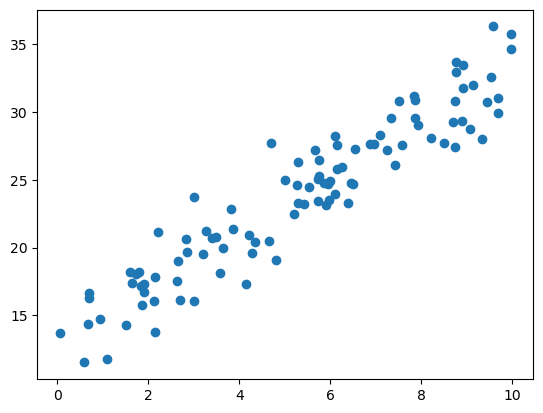

In [48]:
import matplotlib.pyplot as plt

plt.scatter([x[0] for x in data], [x[1] for x in data])
plt.show()

Nuestro objetivo es encontrar una recta que aproxime estos datos lo mejor posible. Este problema se llama *regresión lineal*, y tiene formas mejores de resolverlo que la que vamos a usar. Pero se puede aprender incluso de soluciones subóptimas!

Empezamos parametrizando el objeto que queremos encontrar, en este caso
$$
\text{recta} \equiv y = ax + b
$$
Tenemos dos números reales que queremos encontrar: $(a,b)$.

¿Qué queremos minimizar? El error total, que en este caso es la media de la los cuadrados de las distancias (verticales, no en dirección perpendicular) de cada punto a nuestra recta.

Para un punto $(x,y)$ ¿cómo se calcula la distancia de $(x,y)$ a nuestra recta?
$$
y - (ax+b)
$$
De forma que el error total es:
$$
\operatorname{Error(a,b)} = \frac{1}{\#(\mathcal{P})}\sum_{(x,y) \in \mathcal{P}} (y - (a x + b))^2
$$
(donde $\mathcal{P}$ es el conjunto de puntos que nos dan)

Define una función `total_err` que calcule el error total y y otra `grad_err` que calcule el gradiente del error total evaluado en un punto $(a,b)$ arbitrario.

In [49]:
def total_err(data, a, b):
    i=0
    total=0
    for punto in data:
        i=i+1
        total=total+(punto[1]-(a*punto[0]+b))**2
    return total/i

def grad_err(data, a, b):
    ret = np.array([0.0,0.0])
    i=0
    for punto in data:
        i=i+1
        ret = ret + np.array([2*(punto[1]-(a*punto[0]+b))*-a,2*(punto[1]-(a*punto[0]+b))])
    return ret/i


Con estas funciones ya podemos implementar el algoritmo. Es posible que el gradiente sea muy grande en algunos puntos, lo cual puede hacer que la sucesión de puntos diverja. Podemos "arreglar" el problema normalizando el gradiente cuando sea demasiado grande, por ejemplo:
```
norm = np.linalg.norm(grad)
if norm > 1:
    grad /= norm
```

Programa el algoritmo empezando en un punto cualquiera:

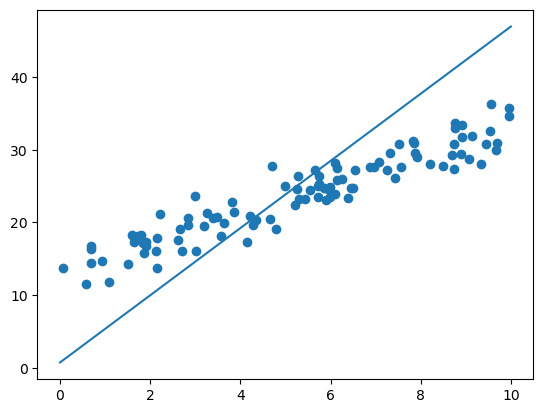

4.623922344279388 0.7300990497625586


In [50]:
a,b = (4,4)

for i in range(100):
    grad=grad_err(data,a,b)
    norm = np.linalg.norm(grad)
    if norm > 1:
        grad /= norm
        
    (a,b)=(a,b)-grad
    
plt.scatter([x[0] for x in data], [x[1] for x in data])
plt.plot(np.linspace(0,10), [a*x + b for x in np.linspace(0,10)])
plt.show()
print(a,b)